<h1 style="color:magenta;">NSL - Exercises 08 </h1>

### 30/4/2026
### Giulia Federica Bianca Coppi (84486A)

## Ex 1

In the `Ex_8_1` directory, you can find the `main.cpp` file where I implemented a **Variational Monte Carlo (VMC)** code for a single quantum particle in 1D. The code exploits the **Metropolis algorithm** to sample the square modulus of the trial wave function $|\Psi_T^{\sigma,\mu}(x)|^2$ using a uniform transition probability $T(x_{\text{new}}|x_{\text{old}})$. 

Using data blocking, the code computes the expectation value of the Hamiltonian:

$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} = 
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)}
$$

which is the quantity to be minimized as a function of the parameters $\mu$ and $\sigma$. We set $\hbar = 1$ and $m=1$.

To evaluate $\langle {\hat H} \rangle_T$, I implemented the analytical calculation of the local energy:
    
$$
\frac{-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)}
$$

within the `H_psi` function in `functions.h`.

The Metropolis algorithm was used to sample the distribution $|\Psi_T^{\sigma,\mu}(x)|^2$. This algorithm constructs a Markov chain of positions that converges to the desired equilibrium distribution without requiring knowledge of the normalization constant. At each step, a new position $x_{\text{new}}$ is proposed from the current position $x_{\text{old}}$ by adding a random displacement drawn from a symmetric uniform distribution. The transition from $x_{\text{old}}$ to $x_{\text{new}}$ is accepted with the Metropolis probability: $$A(x_{old} \rightarrow x_{new})=\min \left(1, \frac{|\Psi_T^{\sigma,\mu}(x_{new})|^2}{|\Psi_T^{\sigma,\mu}(x_{old})|^2}\right) $$

To ensure proper sampling, I tuned the step size $\delta$ of the uniform transition probability to achieve an acceptance rate of $50\% \pm 5\%$. The corresponding tuning function is also located in `functions.h`.

Below are two examples showing the trends of $\langle H \rangle$ with its uncertainty, the acceptance rate, and the sampled wave function PDF for two test pairs $(\mu, \sigma)$.

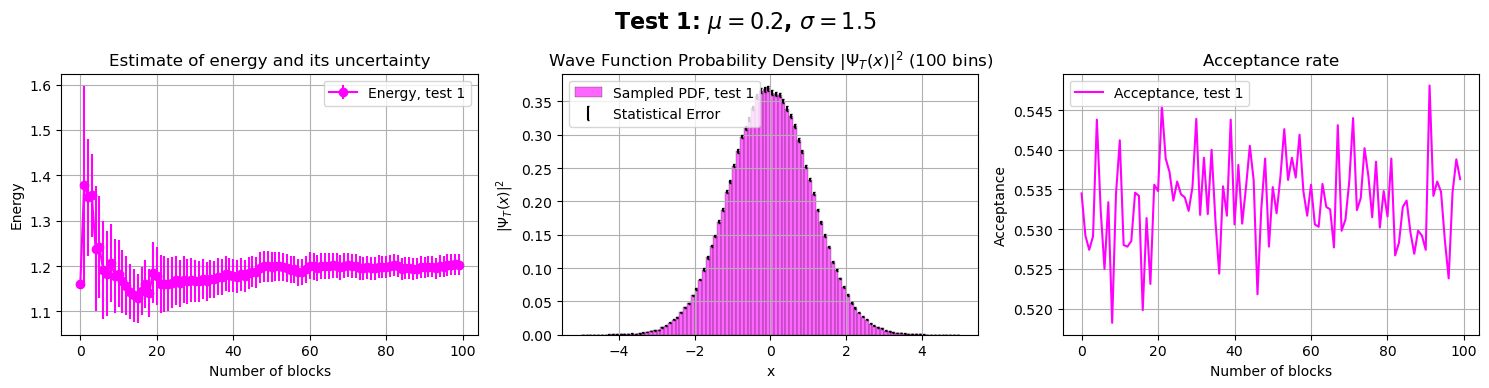

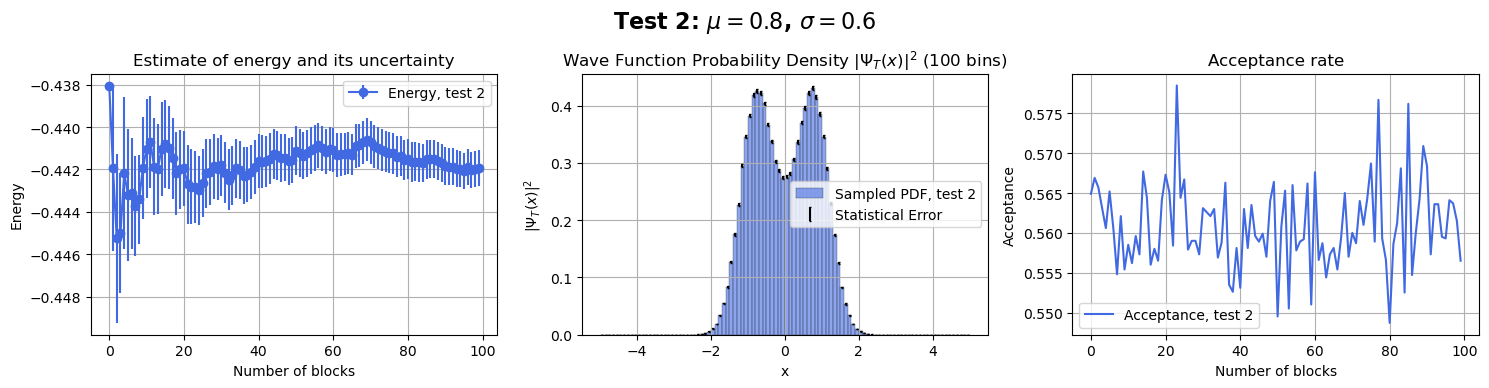

In [78]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
fig2, ax2 = plt.subplots(1, 3, figsize=(15, 4))


#ENERGY

E_1 = np.loadtxt("data_analysis/energy_test_1.dat")
E_2 = np.loadtxt("data_analysis/energy_test_2.dat")

x_1 = E_1[:, 0]      #Number of blocks
y_1 = E_1[:, 1]      #Value
error_1 = E_1[:, 2]  #Standard deviation of the mean

x_2 = E_2[:, 0]      #Number of blocks
y_2 = E_2[:, 1]      #Value
error_2 = E_2[:, 2]  #Standard deviation of the mean

ax[0].errorbar(x_1, y_1, yerr=error_1, label="Energy, test 1", fmt = "o-", color='magenta')
ax[0].set_xlabel("Number of blocks")
ax[0].set_ylabel("Energy")
ax[0].set_title("Estimate of energy and its uncertainty")
ax[0].legend()
ax[0].grid()

ax2[0].errorbar(x_2, y_2, yerr=error_2, label="Energy, test 2", fmt = "o-", color='royalblue')
ax2[0].set_xlabel("Number of blocks")
ax2[0].set_ylabel("Energy")
ax2[0].set_title("Estimate of energy and its uncertainty")
ax2[0].legend()
ax2[0].grid()

#PDF
PDF_1 = np.loadtxt("data_analysis/hist_test_1.dat")
PDF_2 = np.loadtxt("data_analysis/hist_test_2.dat")


x_1 = PDF_1[:, 1]    #x coord, bin center
psi_1 = PDF_1[:, 2]  #bin value normalized
err_1 = PDF_1[:, 3]  #statistical error

x_2 = PDF_2[:, 1]    #x coord, bin center
psi_2 = PDF_2[:, 2]  #bin value normalized
err_2 = PDF_2[:, 3]  #statistical error

#exact bin width
width_1 = x_1[1] - x_1[0]
width_2 = x_2[1] - x_2[0]

ax[1].bar(x_1, psi_1, width=width_1, color='magenta', alpha=0.6, edgecolor='black', linewidth=0.3, label='Sampled PDF, test 1')
ax[1].errorbar(x_1, psi_1, yerr=err_1, fmt='none', ecolor='black', capsize=1, label='Statistical Error')
ax[1].set_title("Wave Function Probability Density $|\Psi_T(x)|^2$ (100 bins)")
ax[1].set_xlabel("x")
ax[1].set_ylabel("$|\Psi_T(x)|^2$")
ax[1].grid(True)
ax[1].legend()

ax2[1].bar(x_2, psi_2, width=width_2, color='royalblue', alpha=0.6, edgecolor='black', linewidth=0.3, label='Sampled PDF, test 2')
ax2[1].errorbar(x_2, psi_2, yerr=err_2, fmt='none', ecolor='black', capsize=1, label='Statistical Error')
ax2[1].set_title("Wave Function Probability Density $|\Psi_T(x)|^2$ (100 bins)")
ax2[1].set_xlabel("x")
ax2[1].set_ylabel("$|\Psi_T(x)|^2$")
ax2[1].grid(True)
ax2[1].legend()

#ACCEPTANCE

A_1 = np.loadtxt("data_analysis/acceptance_test_1.dat")
A_2 = np.loadtxt("data_analysis/acceptance_test_2.dat")

x_1 = A_1[:, 0]      #Number of blocks
y_1 = A_1[:, 1]      #Value

x_2 = A_2[:, 0]      #Number of blocks
y_2 = A_2[:, 1]      #Value

ax[2].plot(x_1, y_1, label="Acceptance, test 1", color='magenta')
ax[2].set_xlabel("Number of blocks")
ax[2].set_ylabel("Acceptance")
ax[2].set_title("Acceptance rate")
ax[2].legend()
ax[2].grid()

ax2[2].plot(x_2, y_2, label="Acceptance, test 2", color='royalblue')
ax2[2].set_xlabel("Number of blocks")
ax2[2].set_ylabel("Acceptance")
ax2[2].set_title("Acceptance rate")
ax2[2].legend()
ax2[2].grid()

fig.tight_layout(rect=[0, 0, 1, 0.90])
fig.suptitle('Test 1: $\mu = 0.2$, $\sigma = 1.5$', fontsize=16, fontweight='bold', y=0.96)
fig2.tight_layout(rect=[0, 0, 1, 0.90])
fig2.suptitle('Test 2: $\mu = 0.8$, $\sigma = 0.6$', fontsize=16, fontweight='bold', y=0.96)

plt.show()

## Ex 2

To determine the values of $\mu$ and $\sigma$ that minimize the expectation value of the Hamiltonian:

$$
\langle {\hat H} \rangle_T = \frac{\langle \Psi_T^{\sigma,\mu} | {\hat H} | \Psi_T^{\sigma,\mu} \rangle}{\langle \Psi_T^{\sigma,\mu} | \Psi_T^{\sigma,\mu} \rangle}
$$

the Variational Monte Carlo (VMC) code was extended by implementing a **Simulated Annealing (SA)** algorithm. This approach is a powerful stochastic optimization technique inspired by the physical process of slowly cooling a system to reach its lowest energy state. 

The SA algorithm is initialized by selecting a starting set of parameters $(\mu_0, \sigma_0)$. At each step, a small random variation is proposed for both $\mu$ and $\sigma$, subject to the following constraints:
* $\sigma > 0$ (only positive values are physically acceptable)
* $\sigma > 0.1$ (excessively small values could lead to inefficient sampling)

For each temperature $T$, a total of $N_{\text{steps}} = 100$ steps are performed. The new energy is evaluated, and the proposed configuration is accepted according to the Metropolis-like criterion:

$$
P = \min\left(1, e^{-\frac{\Delta E}{T}}\right)
$$

where $\Delta E = \langle {\hat H} \rangle_{\text{new}} - \langle {\hat H} \rangle_{\text{old}}$ represents the energy difference between the new and old parameter configurations. This probabilistic rule occasionally permits "uphill moves," enabling the system to escape from local minima and increasing the likelihood of converging toward the global minimum. 

The step size for the parameter variation was chosen to be proportional to the temperature $T$, specifically, it was set to $\delta_SA = 0.5 \cdot T$ to ensure a stable and consistent acceptance rate throughout the simulation.

To guarantee convergence, the temperature is progressively lowered through `T *= 0.98` within the range $[2.5, 0.01]$. At every single step of the annealing process, $\langle {\hat H} \rangle_T$ is computed through the previously implemented Monte Carlo sampling routine, which is encapsulated in the `simulate_H()` function in `functions.h`.

The plot below shows the trend of the expectation value $\langle {\hat H} \rangle_T$ as a function of the SA steps (or temperature). A systematic reduction in the variational energy is clearly visible as the system cools down. This approach allowed for an efficient exploration of the $(\mu, \sigma)$ parameter space, ultimately optimizing the trial wave function's approximation of the true quantum ground state for the system under study.

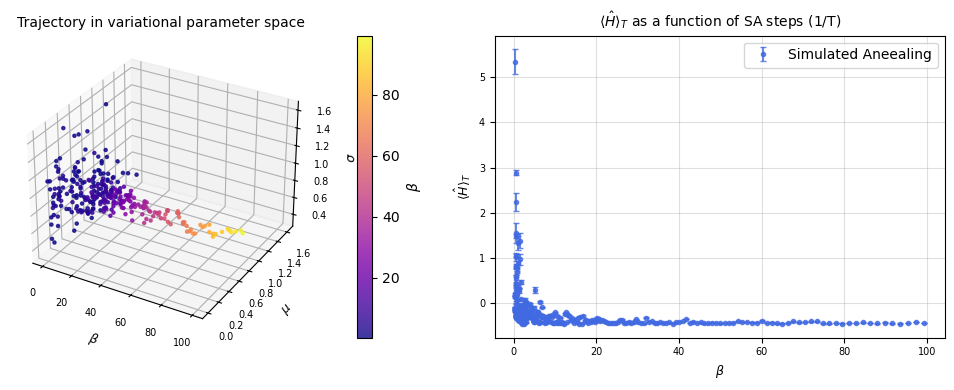

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

T, mu, sigma, H, err = np.loadtxt("data_analysis/output_8_2.dat", unpack=True, usecols=(0,1,2,3,4))
beta = 1 / T

fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc = ax1.scatter(beta, mu, sigma,
                 c=beta,
                 cmap='plasma',
                 marker='.',
                 s=20,
                 alpha=0.8)

ax1.set_xlabel(r"$\beta$", fontsize=9)
ax1.set_ylabel(r"$\mu$", fontsize=9)
ax1.set_zlabel(r"$\sigma$", fontsize=9)
ax1.set_title('Trajectory in variational parameter space', fontsize=10)
ax1.tick_params(axis='both', which='major', labelsize=7)
cbar = fig.colorbar(sc, ax=ax1, pad=0.1)
cbar.set_label(r'$\beta$', fontsize=10)

ax2 = fig.add_subplot(1, 2, 2)
ax2.errorbar(beta, H, yerr=err, fmt='o', markersize=3, capsize=2, color='royalblue', alpha=0.8, label = "Simulated Aneealing")
ax2.set_xlabel(r"$\beta$", fontsize=9)
ax2.set_ylabel(r"$\langle {\hat H} \rangle_T$", fontsize=9)
ax2.set_title(r"$\langle {\hat H} \rangle_T$ as a function of SA steps (1/T)", fontsize=10)
ax2.grid(True, alpha=0.4)
ax2.tick_params(axis='both', which='major', labelsize=7)
ax2.legend()

plt.tight_layout()
plt.show()

At the end of my SA simulation, the set of parameters that minimizes $\langle {\hat H} \rangle_T$ is $(\mu_{\text{best}}, \sigma_{\text{best}}) = (0.797172, 0.569287)$. I used these optimized parameters in the VMC code from Exercise 08.1 to compute $\langle {\hat H} \rangle_T$ and its statistical uncertainty as a function of the number of blocks.

The resulting plot is shown below, alongside the sampled probability density $|\Psi_T(x)|^2$ reconstructed by histogramming the sampled spatial configurations. For comparison, the plot also features the analytical curve of $|\Psi_T(x)|^2$ and the exact numerical solution calculated by discretizing the Schrödinger equation into a matrix equation.

Ground state energy:  -0.4604599857430418


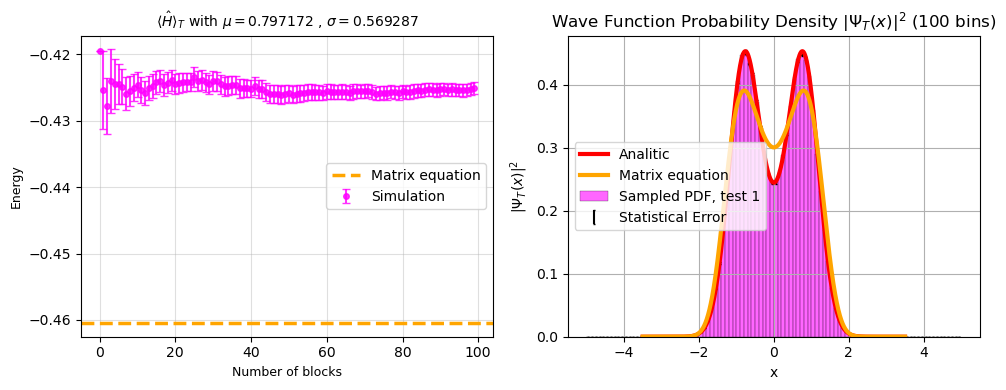

In [77]:
import numpy as np
import matplotlib.pyplot as plt

#square modulus of the wave function
def mod_wave2(x, mu, sigma):
    return (np.exp(-(x-mu)**2/(2*sigma**2))+np.exp((-(x+mu)**2/(2*sigma**2))))**2

def Vpot(x):
    return (x**2 - 2.5)*x**2

hbar = 1
m = 1
a = 7
N = 1000 # number of iterations

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2
CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

print("Ground state energy: ", E[0])

block, Energy, yerr = np.loadtxt("data_analysis/energy_test_3.dat", usecols=(0, 1, 2), unpack=True)
PDF = np.loadtxt("data_analysis/hist_test_3.dat")

wave_3 = PDF[-100:]
x_3 = wave_3[:, 1]    #x coord, bin center
psi_3 = wave_3[:, 2]  #bin value normalized
err_3 = wave_3[:, 3]  #statistical error

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.errorbar(block, Energy, yerr=yerr, fmt='o', capsize=3, markersize=4, color='magenta', alpha=0.8, label='Simulation')
ax1.axhline(E[0], color='orange', linestyle='--', linewidth=2.5, label="Matrix equation")
ax1.set_xlabel("Number of blocks", fontsize=9)
ax1.set_ylabel("Energy", fontsize=9)
ax1.set_title(r"$\langle {\hat H} \rangle_T$ with $\mu = 0.797172$ , $\sigma = 0.569287$", fontsize=10)
ax1.grid(True, alpha=0.4)
ax1.legend()

#exact bin width
width_3 = x_3[1] - x_3[0]

ax2.bar(x_3, psi_3, width=width_3, color='magenta', alpha=0.6, edgecolor='black', linewidth=0.3, label='Sampled PDF, test 1')
ax2.errorbar(x_3, psi_3, yerr=err_3, fmt='none', ecolor='black', capsize=1, label='Statistical Error')
ax2.plot(x, 1. / (2 * 0.569287 * np.sqrt(np.pi) * (1 + np.exp(-(0.797172**2) / (0.569287**2)))) * mod_wave2(x, 0.797172, 0.569287), linewidth = 3 ,color='red', label = r"Analitic")
ax2.plot(x,(psi[0])**2, color = 'orange' , linewidth = 3, label = 'Matrix equation')
ax2.set_title("Wave Function Probability Density $|\Psi_T(x)|^2$ (100 bins)")
ax2.set_xlabel("x")
ax2.set_ylabel("$|\Psi_T(x)|^2$")
ax2.grid(True)
ax2.legend()

plt.legend()
plt.tight_layout()
plt.show()



The ground state energy obtained through the SA simulation is $\langle H\rangle _T = $, statistically not acceptable with the Matrix equation result.

Moreover, the wave function does not match the theoretical shape.

This results come from the theoretical limits of the variational principle.


The ground state energy obtained through the Simulated Annealing optimization is $\langle H\rangle_T = -0.425045 \pm 0.000925563$, which is statistically incompatible with the exact numerical result obtained via the matrix equation. Consequently, the optimized trial wave function does not perfectly match the exact theoretical profile. 

This discrepancy does not stem from a failure of the variational method itself, but rather highlights the intrinsic limitations of our chosen ansatz solution.